Epsilon-greediness
Trong bài tập này, bạn sẽ hiện thực hàm select_action() áp dụng epsilon-greediness có suy giảm theo thời gian.

Epsilon-greediness sẽ khuyến khích agent của bạn khám phá môi trường, từ đó cải thiện việc học!

Lịch epsilon-greediness xác định một ngưỡng 
 cho mỗi step, theo công thức:
 
 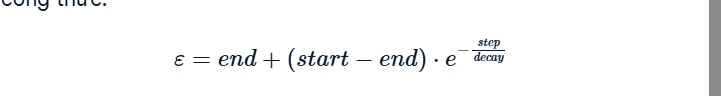

select_action() nên trả về một hành động ngẫu nhiên với xác suất 
, và hành động có Q-value cao nhất với xác suất 
.

Hướng dẫn
100 XP
Tính ngưỡng epsilon cho giá trị step đã cho.
Lấy một số ngẫu nhiên trong khoảng từ 0 đến 1.
Với xác suất epsilon, trả về một hành động ngẫu nhiên.
Với xác suất 1-epsilon, trả về hành động có Q-value cao nhất.

In [ ]:
def select_action(q_values, step, start, end, decay):
    # Calculate the threshold value for this step
    epsilon = end + (____) * math.exp(____ / ____)
    # Draw a random number between 0 and 1
    sample = random.____
    if sample < epsilon:
        # Return a random action index
        return random.____
    # Return the action index with highest Q-value
    return torch.____.item()
      
for step in [1, 500, 2500]:
    actions = [select_action(torch.Tensor([1, 2, 3, 5]), step, .9, .05, 1000) for _ in range(20)]
    print(f"Selecting 20 actions at step {step}.\nThe action with highest q-value is action 3.\nSelected actions: {actions}\n\n")

In [ ]:
"""
Một phần của việc tính ngưỡng epsilon cần lấy hiệu giữa các giá trị start và end, và tính hệ số suy giảm mũ bằng math.exp() với số mũ là -step / decay.
Hàm random() trong mô-đun random mặc định trả về một số trong khoảng từ 0 đến 1.
Để lấy một hành động ngẫu nhiên, dùng random.choice(list) trong đó list là danh sách các chỉ số hành động có thể.
Dùng torch.argmax() để lấy chỉ số của giá trị lớn nhất trong một tensor.


def select_action(q_values, step, start, end, decay):
    # Calculate the threshold value for this step
    epsilon = end + (start-end) * math.exp(-step / decay)
    # Draw a random number between 0 and 1
    sample = random.random()
    if sample < epsilon:
        # Return a random action index
        return random.choice(range(len(q_values)))
    # Return the action index with highest Q-value
    return torch.argmax(q_values).item()

for step in [1, 500, 2500]:
    actions = [select_action(torch.Tensor([1, 2, 3, 5]), step, .9, .05, 1000) for _ in range(20)]
    print(f"Selecting 20 actions at step {step}.\nThe action with highest q-value is action 3.\nSelected actions: {actions}\n\n")
    """

Fixed Q-targets
Bạn đang chuẩn bị huấn luyện Lunar Lander với fixed Q-targets. Trước hết, bạn cần khởi tạo cả online network (chọn hành động) và target network (dùng để tính TD-target).

Bạn cũng cần triển khai hàm update_target_network để dùng ở mỗi bước huấn luyện. Target network không được cập nhật bằng gradient descent; thay vào đó, update_target_network sẽ đẩy trọng số của nó tiến gần về Q-network một lượng nhỏ, giúp nó ổn định theo thời gian.

Lưu ý: chỉ trong bài này, bạn dùng một mạng rất nhỏ để có thể in và quan sát dễ dàng state dictionary. Mạng chỉ có một tầng ẩn kích thước 2; action space và state space cũng có kích thước 2.

Hàm print_state_dict() có sẵn trong môi trường để in state dict.

Hướng dẫn
100 XP
Lấy .state_dict() cho cả target network và online network.
Cập nhật state dict của target network bằng cách lấy trung bình có trọng số giữa các tham số của online network và target network, dùng tau làm trọng số cho online network.
Nạp (load) state dict đã cập nhật trở lại vào target network.

In [1]:
def update_target_network(target_network, online_network, tau):
    # Obtain the state dicts for both networks
    target_net_state_dict = ____
    online_net_state_dict = ____
    for key in online_net_state_dict:
        # Calculate the updated state dict for the target network
        target_net_state_dict[key] = (online_net_state_dict[____] * ____ + target_net_state_dict[____] * ____)
        # Load the updated state dict into the target network
        target_network.____
    return None
  
print("online network weights:", print_state_dict(online_network))
print("target network weights (pre-update):", print_state_dict(target_network))
update_target_network(target_network, online_network, .001)
print("target network weights (post-update):", print_state_dict(target_network))

NameError: name 'print_state_dict' is not defined

In [ ]:
"""
Dùng phương thức .state_dict() để lấy state dict của một mạng nơ-ron.
Nếu tau là trọng số cho online network, thì trọng số cho target network sẽ là 1-tau.
Phương thức .load_state_dict() có thể dùng để nạp một state dict vào mạng nơ-ron.


def update_target_network(target_network, online_network, tau):
    # Obtain the state dicts for both networks
    target_net_state_dict = target_network.state_dict()
    online_net_state_dict = online_network.state_dict()
    for key in online_net_state_dict:
        # Calculate the updated state dict for the target network
        target_net_state_dict[key] = (online_net_state_dict[key] * tau + target_net_state_dict[key] * (1 - tau))
        # Load the updated state dict into the target network
        target_network.load_state_dict(target_net_state_dict)
    return None

print("online network weights:", print_state_dict(online_network))
print("target network weights (pre-update):", print_state_dict(target_network))
update_target_network(target_network, online_network, .001)
print("target network weights (post-update):", print_state_dict(target_network))
"""

Hiện thực thuật toán DQN hoàn chỉnh
Đã đến lúc bắt tay vào làm! Mọi điều kiện tiên quyết đã sẵn sàng; giờ bạn sẽ hiện thực toàn bộ thuật toán DQN và dùng nó để huấn luyện một agent Lunar Lander. Nghĩa là thuật toán của bạn sẽ không chỉ dùng Experience Replay, mà còn có Decayed Epsilon-Greediness và Fixed Q-Targets.

Hàm select_action() hiện thực Decayed Epsilon Greediness đã sẵn sàng để bạn dùng, tương tự như hàm update_target_network() từ bài trước. Việc còn lại là lồng ghép các hàm này vào vòng lặp huấn luyện DQN và đảm bảo bạn dùng đúng Target Network trong phần tính loss.

Bạn cần duy trì một bộ đếm bước mới, total_steps, để giảm dần giá trị của 
 theo thời gian. Biến này đã được khởi tạo sẵn với giá trị 0.

Hướng dẫn
100 XP
Dùng select_action() để hiện thực Decayed Epsilon Greediness và chọn hành động của agent; bạn sẽ cần dùng total_steps, tổng tích lũy qua các episode.
Trước khi tính TD target, hãy tắt theo dõi gradient.
Sau khi có trạng thái kế tiếp, lấy các Q-Value của trạng thái kế tiếp.
Cập nhật target network ở cuối mỗi bước.

In [2]:
for episode in range(10):
    state, info = env.reset()
    done = False
    step = 0
    episode_reward = 0
    while not done:
        step += 1
        total_steps += 1
        q_values = online_network(state)
        # Select the action with epsilon greediness
        action = ____(____, ____, start=.9, end=.05, decay=1000)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        replay_buffer.push(state, action, reward, next_state, done)        
        if len(replay_buffer) >= batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(64)
            q_values = online_network(states).gather(1, actions).squeeze(1)
            # Ensure gradients are not tracked
            with ____:
                # Obtain the next state Q-values
                next_q_values = ____(next_states).amax(1)
                target_q_values = rewards + gamma * next_q_values * (1-dones)
            loss = nn.MSELoss()(q_values, target_q_values)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()   
            # Update the target network weights
            ____(____, ____, tau=.005)
        state = next_state
        episode_reward += reward    
    describe_episode(episode, reward, episode_reward, step)

NameError: name 'env' is not defined

In [ ]:
"""Tham số thứ nhất của select_action() là các Q-value, tham số thứ hai là tổng số bước.
Ngữ cảnh torch.no_grad() được dùng để tắt theo dõi gradient.
Với Q-targets cố định, bạn lấy Q-value của trạng thái kế tiếp từ target network.
Trước đó bạn đã viết hàm update_target_network(target_network, online_network, tau)


for episode in range(10):
    state, info = env.reset()
    done = False
    step = 0
    episode_reward = 0
    while not done:
        step += 1
        total_steps += 1
        q_values = online_network(state)
        # Select the action with epsilon greediness
        action = select_action(q_values, total_steps, start=.9, end=.05, decay=1000)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        replay_buffer.push(state, action, reward, next_state, done)        
        if len(replay_buffer) >= batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(64)
            q_values = online_network(states).gather(1, actions).squeeze(1)
            # Ensure gradients are not tracked
            with torch.no_grad():
                # Obtain the next state Q-values
                next_q_values = target_network(next_states).amax(1)
                target_q_values = rewards + gamma * next_q_values * (1-dones)
            loss = nn.MSELoss()(q_values, target_q_values)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # Update the target network weights
            update_target_network(target_network, online_network, tau=.005)
        state = next_state
        episode_reward += reward    
    describe_episode(episode, reward, episode_reward, step)
    
    """